# Anti-Money Laundering in Bitcoin Transactions

## Study objectives

This study uses the Elliptic Bitcoin transaction graph to:

1. Explore the temporal, class, and graph structure of the dataset.
2. Prepare transaction features and labels without introducing data leakage.
3. Build baseline models for distinguishing licit and illicit transactions.
4. Evaluate models with metrics appropriate for severe class imbalance.
5. Record assumptions, random seeds, dependency versions, and generated artifacts
   so the analysis can be reproduced.

## Dataset

The Elliptic dataset is downloaded separately and is not stored in this
repository. See `docs/dataset.md` for acquisition and placement instructions.

In [1]:
from pathlib import Path # library module for working with file system paths.
import os # library module for interacting with the operating system. 
import platform # library module for getting information about the operating system.
import random # library module for generating random numbers.

import numpy as np # library module for numerical computing with arrays and matrices.
import pandas as pd # library module for data manipulation and analysis.
import sklearn # library module for machine learning and data mining.

RANDOM_SEED = 42 # constant variable for setting the random seed for reproducibility.

os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED) # set the PYTHONHASHSEED environment variable to the random seed value.
random.seed(RANDOM_SEED) # set the random seed for the random module.
np.random.seed(RANDOM_SEED) # set the random seed for the numpy module.



In [2]:
# This function automatically locates your project's main folder so your code can safely load files using consistent relative paths, 
# regardless of where your Jupyter notebook was launched.
def find_project_root(start: Path | None = None) -> Path:
    """Find the project root regardless of where Jupyter was launched."""
    start = (start or Path.cwd()).resolve()

    for candidate in (start, *start.parents):
        if (candidate / "requirements.txt").is_file():
            return candidate

    raise FileNotFoundError(
        "Project root not found. Expected a parent directory containing "
        "'requirements.txt'. Start Jupyter inside this project."
    )

In [3]:
# This code block serves as an environment and dataset validation setup for your project pipeline.
# It ensures your workspace is properly configured and that all required data files exist before executing heavy computations.

# this line calls the find_project_root function to locate the project root 
# directory and assigns it to the PROJECT_ROOT variable.
PROJECT_ROOT = find_project_root() 
# this line constructs the path to the directory where the raw dataset 
# files are expected to be located, based on the project root.
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "elliptic_bitcoin_dataset" 
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

REQUIRED_DATA_FILES = (
    "elliptic_txs_features.csv",
    "elliptic_txs_classes.csv",
    "elliptic_txs_edgelist.csv",
)

missing_files = [
    DATA_DIR / filename
    for filename in REQUIRED_DATA_FILES
    if not (DATA_DIR / filename).is_file()
]

print(f"Project root: {PROJECT_ROOT}")
print(f"Python:       {platform.python_version()}")
print(f"NumPy:        {np.__version__}")
print(f"pandas:       {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"Random seed:  {RANDOM_SEED}")

if missing_files:
    missing_list = "\n".join(f"  - {path}" for path in missing_files)
    raise FileNotFoundError(
        "Elliptic dataset is incomplete or has not been downloaded.\n"
        f"Expected directory: {DATA_DIR}\n"
        f"Missing files:\n{missing_list}\n"
        "Follow docs/dataset.md to obtain the dataset."
    )

print("Dataset check passed: all required files were found.")

Project root: E:\Machine Leraning\ML Project\AML Crypto Complience
Python:       3.13.5
NumPy:        2.5.2
pandas:       3.0.5
scikit-learn: 1.9.0
Random seed:  42
Dataset check passed: all required files were found.


## 2. Data loading and validation

Load the Elliptic transaction features, labels, and payment-flow edges.
Validate their schemas and relationships before performing analysis or modeling.

In [4]:
# foLLOWING ARE THE PATHS TO THE DATA FILES
FEATURES_PATH = DATA_DIR / "elliptic_txs_features.csv"
CLASSES_PATH = DATA_DIR / "elliptic_txs_classes.csv"
EDGES_PATH = DATA_DIR / "elliptic_txs_edgelist.csv"

# The 166 node features consist of:
# - time_step
# - 93 other local transaction features
# - 72 aggregated one-hop features
LOCAL_TRANSACTION_COLUMNS = [
    f"local_feature_{number:03d}"
    for number in range(1, 94)    
]

AGGREGATE_FEATURE_COLUMNS = [
    f"aggregate_feature_{number:03d}"
    for number in range(1,73)
]

NODE_FEATURE_COLUMNS = [
    "time_step",
    *LOCAL_TRANSACTION_COLUMNS,
    *AGGREGATE_FEATURE_COLUMNS,
]

FEATURE_COLUMNS = [
    "transaction_id",
    *NODE_FEATURE_COLUMNS,
]

print(f"Node features: {len(NODE_FEATURE_COLUMNS)}")
print(f"Raw feature columns including ID: {len(FEATURE_COLUMNS)}")

Node features: 166
Raw feature columns including ID: 167


In [5]:
# following dictionary defines the data types for specific features in the dataset.
feature_dtypes = {
    "transaction_id": "int64",
    "time_step": "int16",
}

# update the feature_dtypes dictionary to include all local transaction and aggregate feature columns with a data type of float32.
feature_dtypes.update({
    column: "float32"
    for column in LOCAL_TRANSACTION_COLUMNS + AGGREGATE_FEATURE_COLUMNS
})

features_df = pd.read_csv(
    FEATURES_PATH,
    header=None,
    names=FEATURE_COLUMNS,
    dtype=feature_dtypes,
)

classes_df = (
    pd.read_csv(
        CLASSES_PATH,
        dtype={
            "txId": "int64",
            "class": "string",
        },
    ).rename(columns={"txId": "transaction_id", "class": "raw_class"})
)

edges_df = (
    pd.read_csv(
        EDGES_PATH,
        dtype={
            "txId1": "int64",
            "txId2": "int64",
        },
    ).rename(columns={"txId1": "source_transaction_id", "txId2": "target_transaction_id"})
)

print(f"Features shape: {features_df.shape}")
print(f"Classes shape: {classes_df.shape}")
print(f"Edges shape: {edges_df.shape}")

Features shape: (203769, 167)
Classes shape: (203769, 2)
Edges shape: (234355, 2)


In [6]:
# This section is responsible for cleaning, validating, and standardizing the transaction labels
# before use them for your AML machine-learning model.

classes_df["raw_class"] = (classes_df["raw_class"].str.strip().str.lower())

LABEL_MAP = {
    "1": "illicit",
    "2": "licit",
    "unknown": "unknown"
}

# following line creates a sorted list of unique labels in the classes_df DataFrame 
# that are not present in the LABEL_MAP dictionary.
# (i.e., 1,2, and unknown are recognized labels, 3 or any other label would be unrecognized)
unrecognized_labels = sorted(
    set(classes_df["raw_class"].dropna()) - set(LABEL_MAP)
)
# print(f"Unrecognized labels: {unrecognized_labels}")

# Stop the program if an unexpected label exists
if unrecognized_labels:
    raise ValueError(
        f"Unrecognized labels found in classes_df: {unrecognized_labels}. "
        "Please update the LABEL_MAP dictionary to include these labels."
    )

# Convert raw labels into meaningful labels
classes_df["label"] = classes_df["raw_class"].map(LABEL_MAP)

# Convert label into a categorical variable
classes_df["label"] = pd.Categorical(
    classes_df["label"],
    categories=["licit", "illicit", "unknown"],
)

classes_df["label"].value_counts()

label
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64

In [7]:
# explicit validation function
# This section is a data-validation gate.
# Its purpose is to make sure the three Elliptic dataset files you loaded earlier
#  are actually the expected/canonical dataset before you allow the ML pipeline to continue.

EXPECTED_TRANSACTION_COUNT = 203_769
EXPECTED_EDGE_COUNT = 234_355
EXPECTED_TIME_STEPS = set(range(1, 50))

EXPECTED_LABEL_COUNTS = {
    "licit": 42_019,
    "illicit": 4_545,
    "unknown": 157_205,
}


def require(condition: bool, message: str) -> None:
    """Raise an understandable error when a dataset condition is not met."""
    if not condition:
        raise ValueError(f"Elliptic dataset validation failed: {message}")


def validate_elliptic_data(
    features: pd.DataFrame,
    classes: pd.DataFrame,
    edges: pd.DataFrame,
) -> None:
    """Validate the canonical Elliptic transaction dataset."""

    require(
        features.shape == (EXPECTED_TRANSACTION_COUNT, 167),
        f"feature table has shape {features.shape}; "
        f"expected ({EXPECTED_TRANSACTION_COUNT}, 167)",
    )

    require(
        len(classes) == EXPECTED_TRANSACTION_COUNT,
        f"class table has {len(classes):,} rows; "
        f"expected {EXPECTED_TRANSACTION_COUNT:,}",
    )

    require(
        edges.shape == (EXPECTED_EDGE_COUNT, 2),
        f"edge table has shape {edges.shape}; "
        f"expected ({EXPECTED_EDGE_COUNT}, 2)",
    )

    require(
        list(features.columns) == FEATURE_COLUMNS,
        "feature columns do not match the expected schema",
    )

    require(
        list(edges.columns)
        == ["source_transaction_id", "target_transaction_id"],
        "edge columns do not match the expected schema",
    )

    feature_duplicates = int(
        features["transaction_id"].duplicated().sum()
    )
    class_duplicates = int(
        classes["transaction_id"].duplicated().sum()
    )
    edge_duplicates = int(edges.duplicated().sum())

    require(
        feature_duplicates == 0,
        f"found {feature_duplicates:,} duplicated feature transaction IDs",
    )
    require(
        class_duplicates == 0,
        f"found {class_duplicates:,} duplicated class transaction IDs",
    )
    require(
        edge_duplicates == 0,
        f"found {edge_duplicates:,} duplicated edges",
    )

    require(
        not features.isna().any().any(),
        "the feature table contains missing values",
    )
    require(
        not classes.isna().any().any(),
        "the class table contains missing values",
    )
    require(
        not edges.isna().any().any(),
        "the edge table contains missing values",
    )

    require(
        np.isfinite(
            features[NODE_FEATURE_COLUMNS].to_numpy(copy=False)
        ).all(),
        "the feature table contains infinite values",
    )

    observed_time_steps = set(
        features["time_step"].astype(int).unique()
    )
    require(
        observed_time_steps == EXPECTED_TIME_STEPS,
        f"time steps are {sorted(observed_time_steps)}; expected 1 through 49",
    )

    feature_ids = pd.Index(features["transaction_id"])
    class_ids = pd.Index(classes["transaction_id"])

    missing_class_ids = feature_ids.difference(class_ids)
    orphan_class_ids = class_ids.difference(feature_ids)

    require(
        missing_class_ids.empty,
        f"{len(missing_class_ids):,} transactions have no class record",
    )
    require(
        orphan_class_ids.empty,
        f"{len(orphan_class_ids):,} class records have no feature row",
    )

    valid_source = edges["source_transaction_id"].isin(feature_ids)
    valid_target = edges["target_transaction_id"].isin(feature_ids)

    require(
        valid_source.all(),
        f"{int((~valid_source).sum()):,} edges have an unknown source",
    )
    require(
        valid_target.all(),
        f"{int((~valid_target).sum()):,} edges have an unknown target",
    )

    observed_counts = {
        str(label): int(count)
        for label, count in classes["label"].value_counts().items()
    }

    require(
        observed_counts == EXPECTED_LABEL_COUNTS,
        f"label counts are {observed_counts}; "
        f"expected {EXPECTED_LABEL_COUNTS}",
    )

    print("Elliptic dataset validation passed.")

validate_elliptic_data(features_df, classes_df, edges_df)

Elliptic dataset validation passed.


In [8]:
# Create the clean transaction table

transaction_df = features_df.merge(
    classes_df[["transaction_id", "label"]],
    on="transaction_id",
    how="left",
    validate="one_to_one"
)

print(f"Transaction table shape: {transaction_df.shape}")
print(f"Edges: {edges_df.shape}")
print()
print(transaction_df['label'].value_counts())



# test the validation function with a modified classes_df to simulate a failure case
# try:
#     validate_elliptic_data(
#         features_df,
#         classes_df.iloc[:-1],
#         edges_df,
#     )
# except ValueError as error:
#     print(error)

Transaction table shape: (203769, 168)
Edges: (234355, 2)

label
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64


## 3. Exploratory data analysis

This section examines label coverage, temporal behavior, anonymized feature
distributions, and the transaction graph. All analyses are descriptive.

Unknown labels are not assumed to be licit. Any future feature selection must
be performed using training data only.

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")


LABEL_COLORS = {
    "licit": "#2E8B57",  # SeaGreen
    "illicit": "#C0392B", # Red
    "unknown": "#7F8C8D"  # Dark Gray
}

# 
LABEL_ORDER = ["licit", "illicit", "unknown"]

In [10]:
# Count each label (i.e. Illecit, licit, unknown)
label_counts = (
    transaction_df["label"]
    .value_counts()
    .reindex(LABEL_ORDER)
    .astype(int)
    )

# label_summary -- table with two columns (i.e. count, percentage_of_all_labels)
label_summary = pd.DataFrame({
    "count": label_counts,
    "percentage_of_all_labels": (
        label_counts / len(transaction_df) * 100
    ).round(3),
})

# print(f"Label Summary: {label_summary}")

# isin() indicate boolean value (licit, illicite = TRUE, unknown = FALSE)
labeled_mask = transaction_df["label"].isin(["licit", "illicit"])
# print(labeled_mask.value_counts())

# Create a subset of the transaction_df DataFrame that only includes rows where the label is either "licit" or "illicit".
labeled_df = transaction_df.loc[labeled_mask].copy()

# Calculate the percentage of illicit transactions among the labeled transactions
illicit_rate_labeled = (labeled_df.eq("illicit").mean() * 100).round(3)

display(label_summary)
print("---------------------------------")
print(f"Total transactions:   {len(transaction_df):,}")
print(f"Labeled transactions: {len(labeled_df):,}")
print(f"Label coverage:        {labeled_mask.mean() * 100:.3f}%")
print(f"Unknown coverage:      {(~labeled_mask).mean() * 100:.3f}%")
# print(
#     "Illicit share among labeled transactions: "
#     f"{illicit_rate_labeled:.3f}%"
# )

,count,percentage_of_all_labels
label,,
licit,42019,20.621
illicit,4545,2.230
unknown,157205,77.149


---------------------------------
Total transactions:   203,769
Labeled transactions: 46,564
Label coverage:        22.851%
Unknown coverage:      77.149%


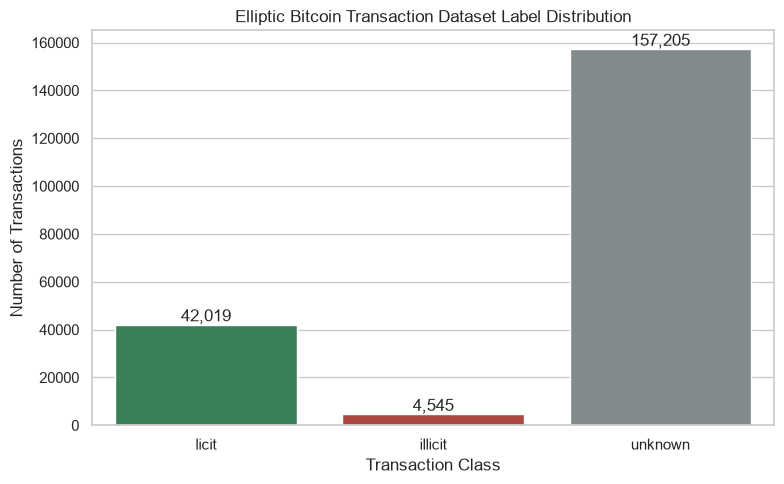

In [11]:
# A bar chart showing the NUMBER of transactions in each class (licit, illicit, unknown) in Elliptic AML dataset.

plot_summary = (
    label_summary
    .reset_index()
    .rename(columns={"label": "class"})
)

fig, ax = plt.subplots(figsize=(8,5))

sns.barplot(
    plot_summary,
    x="class",
    y="count",
    hue="class",
    palette=LABEL_COLORS,
    legend=False,
    ax=ax
)

# Add value count labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}")

ax.set(
    title="Elliptic Bitcoin Transaction Dataset Label Distribution",
    xlabel="Transaction Class",
    ylabel="Number of Transactions"
)

plt.tight_layout()
plt.show()

In [44]:
# Analyze labels over time

time_label_count = (
    transaction_df
    .groupby(["time_step", "label"], observed=True)
    .size() # count the number of transactions for each time_step
    .unstack(fill_value=0) # convert rows to columns to create a DataFrame with time_step 
    .reindex(columns=LABEL_ORDER, fill_value=0) # ensure the columns are in the order of LABEL_ORDER
)

# Separate DataFrame containing the same information.
time_summary = time_label_count.copy()

# Column # 1
time_summary["total"] = time_label_count.sum(axis=1)

# Column # 2
time_summary["labeled"] = (
    time_label_count["licit"] + time_label_count["illicit"]
)

# Column # 3
time_summary["label_coverage_pct"] = (
    time_summary["labeled"] / time_summary["total"] * 100
)

# Column # 4
time_summary["illicite_rate_labeled_pct"] = (
    time_summary["illicit"] / time_summary["total"] * 100
)
display(time_summary)

label,licit,illicit,unknown,total,labeled,label_coverage_pct,illicite_rate_labeled_pct
time_step,,,,,,,
1,2130,17,5733,7880,2147,27.246193,0.215736
2,1099,18,3427,4544,1117,24.581866,0.396127
3,1268,11,5342,6621,1279,19.317324,0.166138
4,1410,30,4253,5693,1440,25.294221,0.526963
5,1874,8,4921,6803,1882,27.664266,0.117595
6,480,5,3843,4328,485,11.206100,0.115527
7,1101,102,4845,6048,1203,19.890873,1.686508
8,1098,67,3292,4457,1165,26.138658,1.503253
9,530,248,4218,4996,778,15.572458,4.963971


C:\Users\Pc Planet\AppData\Local\Temp\ipykernel_27552\3496677527.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()
C:\Users\Pc Planet\AppData\Local\Temp\ipykernel_27552\3496677527.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend()


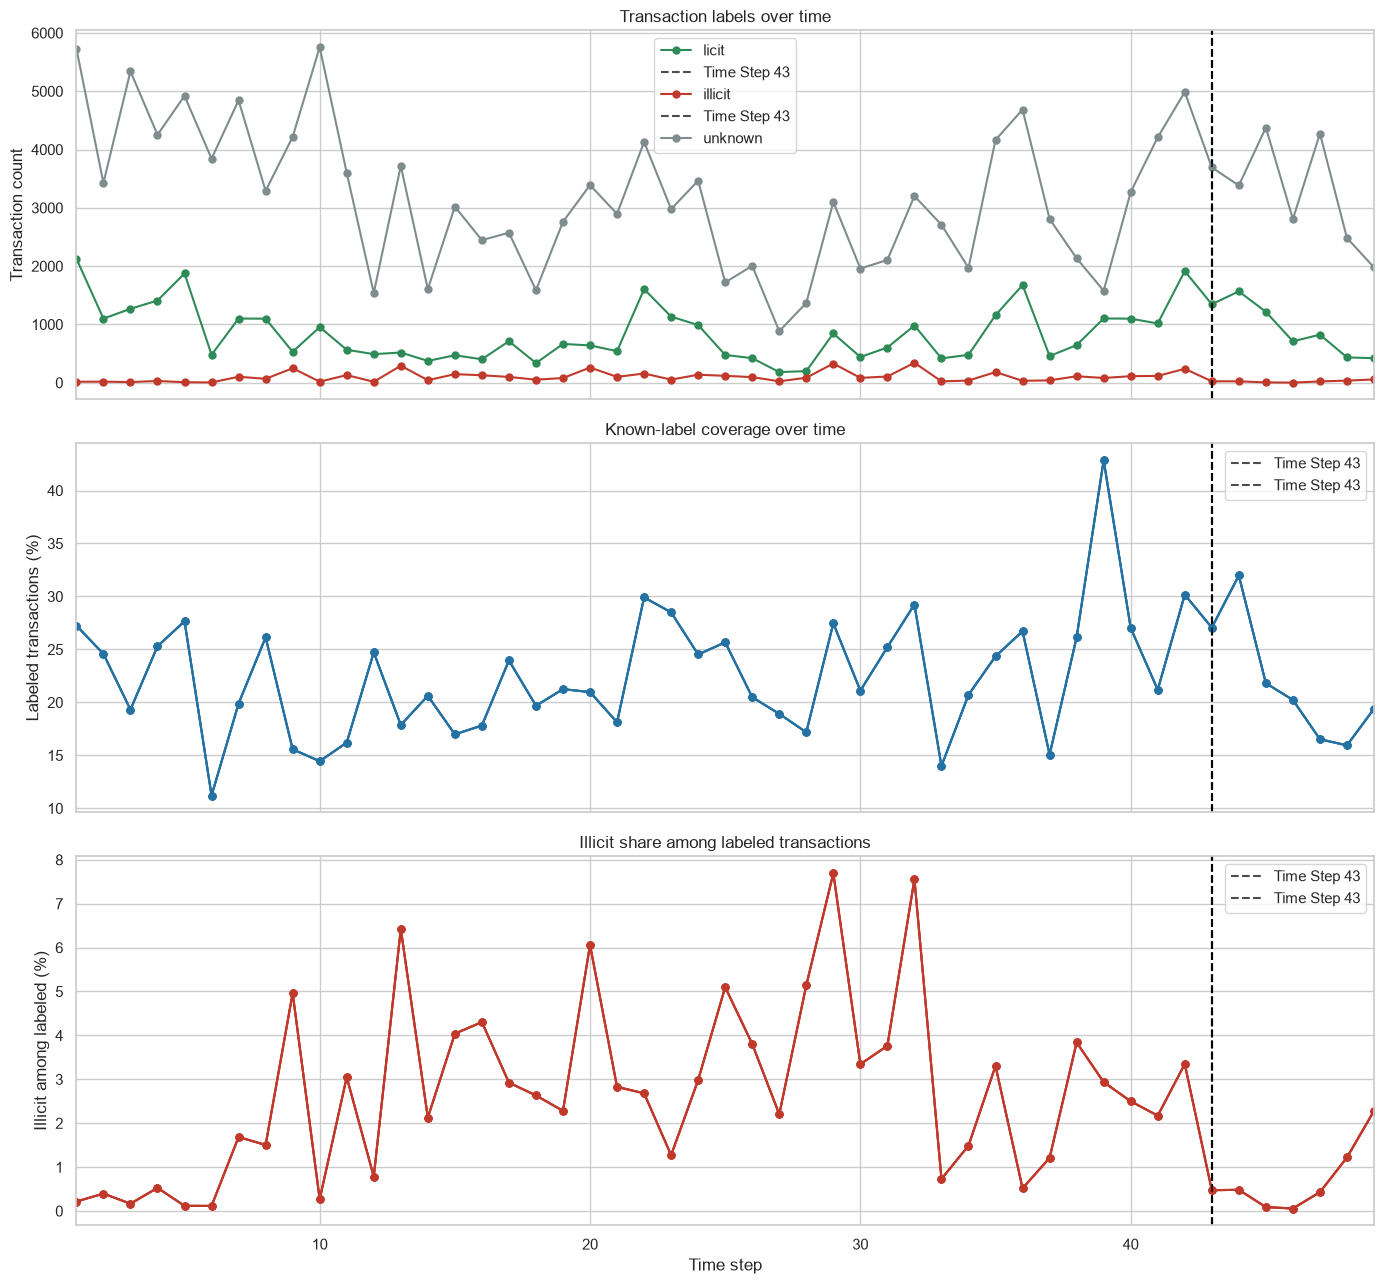

In [59]:
# Create three temporal plots

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(14,13),
    sharex=True
)

for label in LABEL_ORDER:
    # Plot: 1
    axes[0].plot(
        time_label_count.index,
        time_label_count[label],
        marker="o",
        markersize=5,
        label=label,
        color=LABEL_COLORS[label]
    )
    axes[0].set(
        title="Transaction labels over time",
        ylabel="Transaction count",
    )
    axes[0].legend()

    # Plot: 2
    axes[1].plot(
        time_summary.index,
        time_summary["label_coverage_pct"],
        color="#2471A3",
        marker="o",
        markersize=5
    )
    axes[1].set(
        title="Known-label coverage over time",
        ylabel="Labeled transactions (%)"
    )
    axes[1].legend()

    # Plot: 3
    axes[2].plot(
        time_summary.index,
        time_summary["illicite_rate_labeled_pct"],
        color=LABEL_COLORS["illicit"],
        marker="o",
        markersize=5
    )

    axes[2].set(
        title="Illicit share among labeled transactions",
        xlabel="Time step",
        ylabel="Illicit among labeled (%)",
    )
    axes[2].legend()

    for ax in axes:
        ax.axvline(
            43,
            color="black",
            linestyle="--",
            alpha=0.7,
            label="Time Step 43"
        )
    ax.set_xlim(1, 49)
plt.tight_layout()
plt.show()


In [60]:
display(transaction_df)

,transaction_id,time_step,local_feature_001,local_feature_002,local_feature_003,local_feature_004,local_feature_005,local_feature_006,local_feature_007,local_feature_008,...,aggregate_feature_064,aggregate_feature_065,aggregate_feature_066,aggregate_feature_067,aggregate_feature_068,aggregate_feature_069,aggregate_feature_070,aggregate_feature_071,aggregate_feature_072,label
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782743,12.414557,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,licit
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203764,173077460,49,-0.145771,-0.163752,0.463609,-0.121970,-0.043875,-0.113002,-0.061584,-0.135803,...,-0.613614,0.241128,0.241406,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
203765,158577750,49,-0.165920,-0.123607,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.156418,...,0.010822,1.461330,1.461369,-0.098889,-0.087490,-0.084674,-0.140597,-1.760926,-1.760984,unknown
203766,158375402,49,-0.172014,-0.078182,1.018602,0.028105,-0.043875,0.054722,-0.061584,-0.163626,...,1.985050,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,illicit
203767,158654197,49,-0.172842,-0.176622,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.163501,...,-0.411776,1.461330,1.461369,-0.098889,-0.087490,-0.084674,-0.140597,1.519700,1.521399,unknown
